In [10]:
import matplotlib.pyplot as plt
import gvar as gv
import numpy as np
import pathlib
from cycler import cycler

from hadrana.loader import load_c2pt_per_nsquare, load_fits

In [11]:
ensemble = "D251"
correlation_type = "correlated"
bin_size = 2

run_id  = "test-run26"
run_dir = pathlib.Path(f"/home/ck/phd/results/c2pt/D251/D251-c2pt-fits-{run_id}")

# load c2pt data
momentum_shells = [0, 1, 2, 3, 4, 5, 6, 8]
c2pt_per_nsquare = load_c2pt_per_nsquare(ensemble, momentum_shells, bin_size)

/tmp/ipykernel_360302/1076170026.py:47: RuntimeWarning: invalid value encountered in log
  Eeff     = np.log(c2pt[:, :-1] / c2pt[:, 1:])
/tmp/ipykernel_360302/1076170026.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap  = cm.get_cmap("viridis")


1.1734381560295521


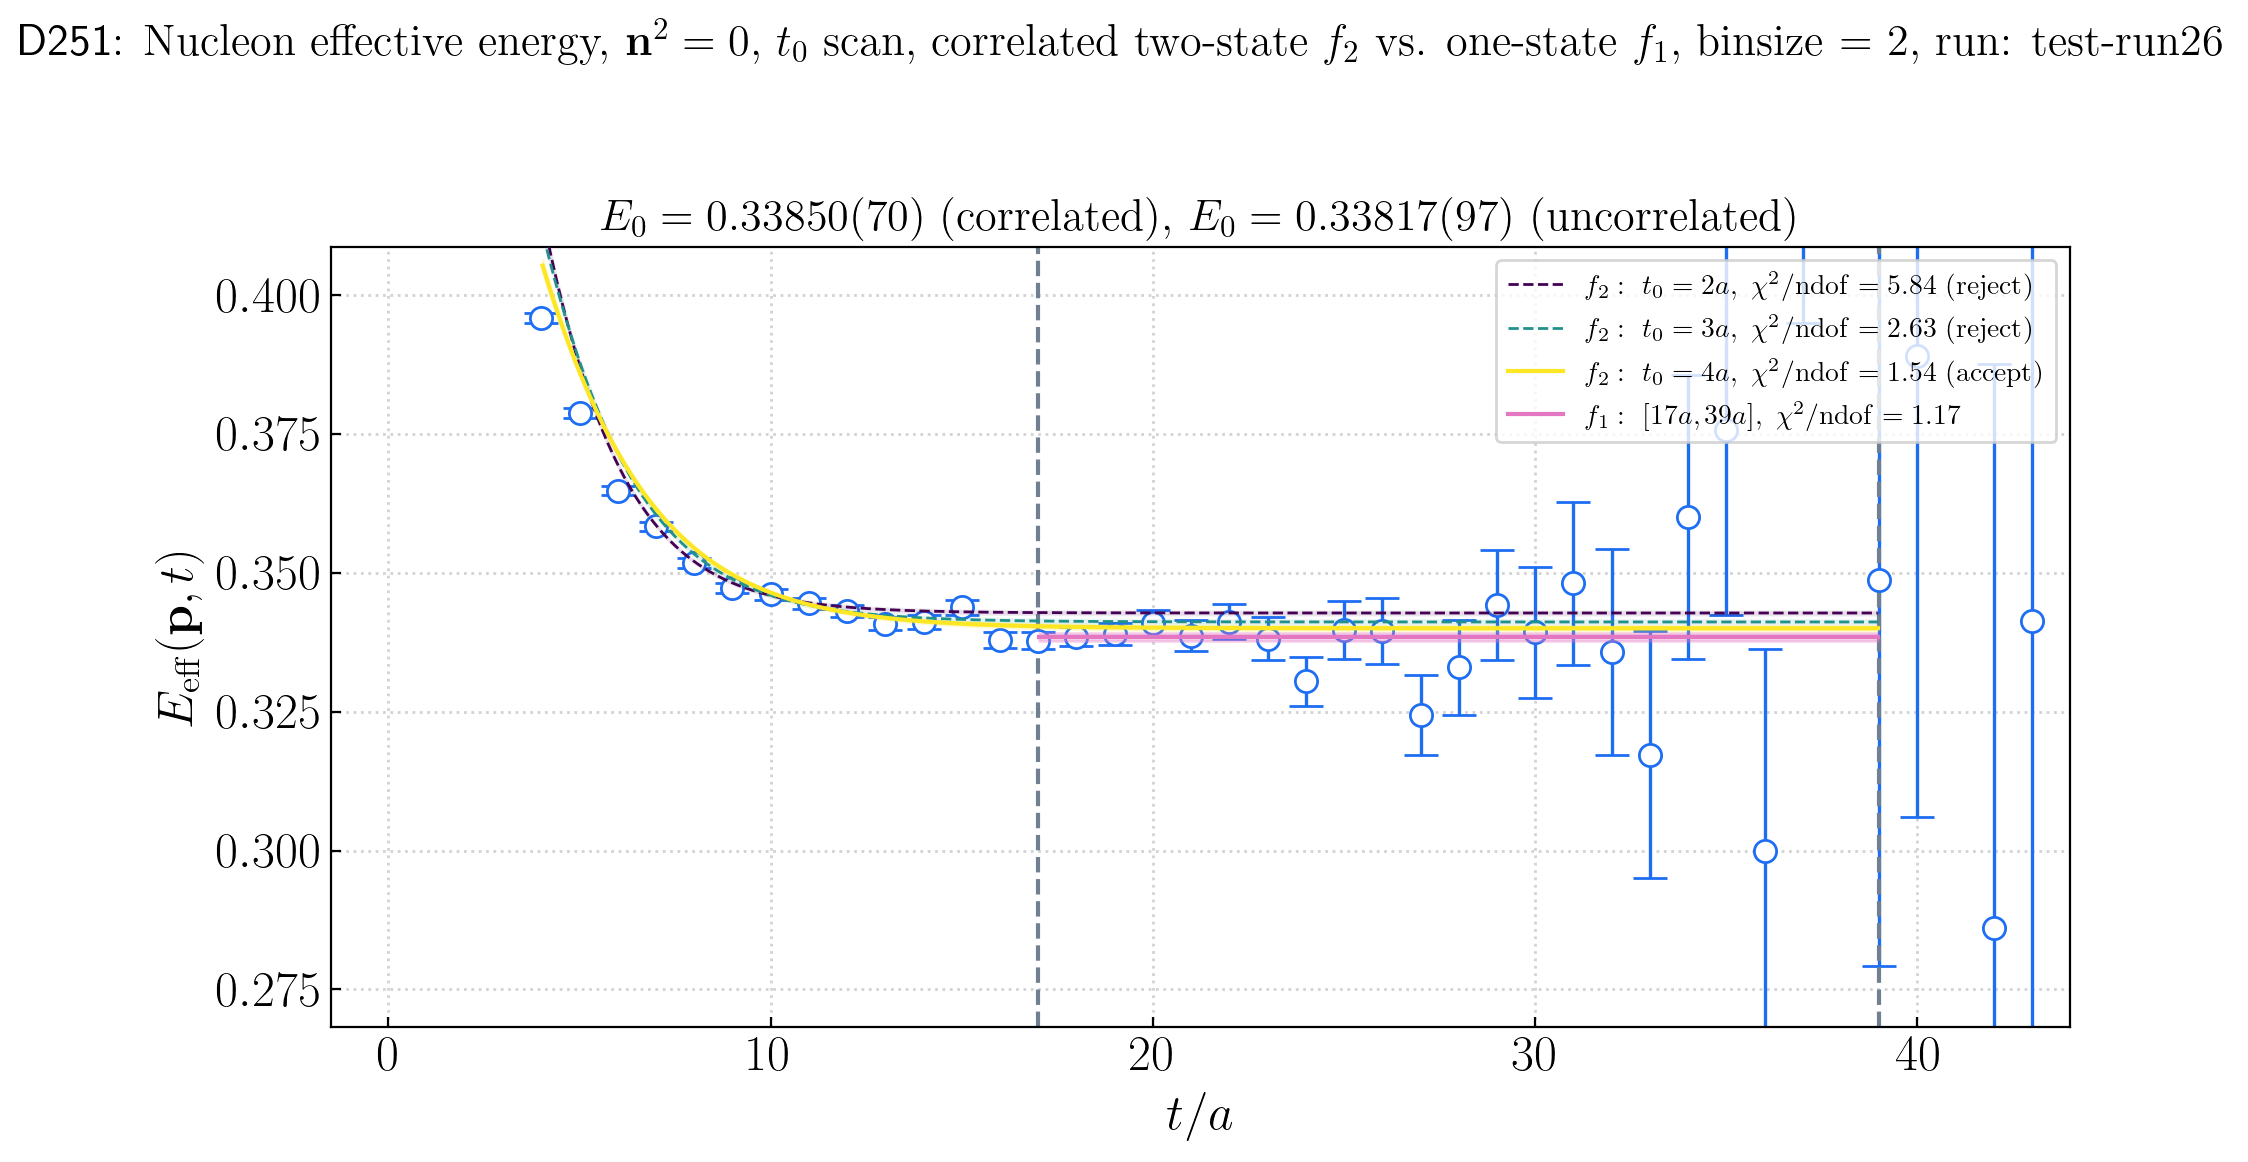

/tmp/ipykernel_360302/1076170026.py:47: RuntimeWarning: invalid value encountered in log
  Eeff     = np.log(c2pt[:, :-1] / c2pt[:, 1:])
/tmp/ipykernel_360302/1076170026.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap  = cm.get_cmap("viridis")


1.081736172348938


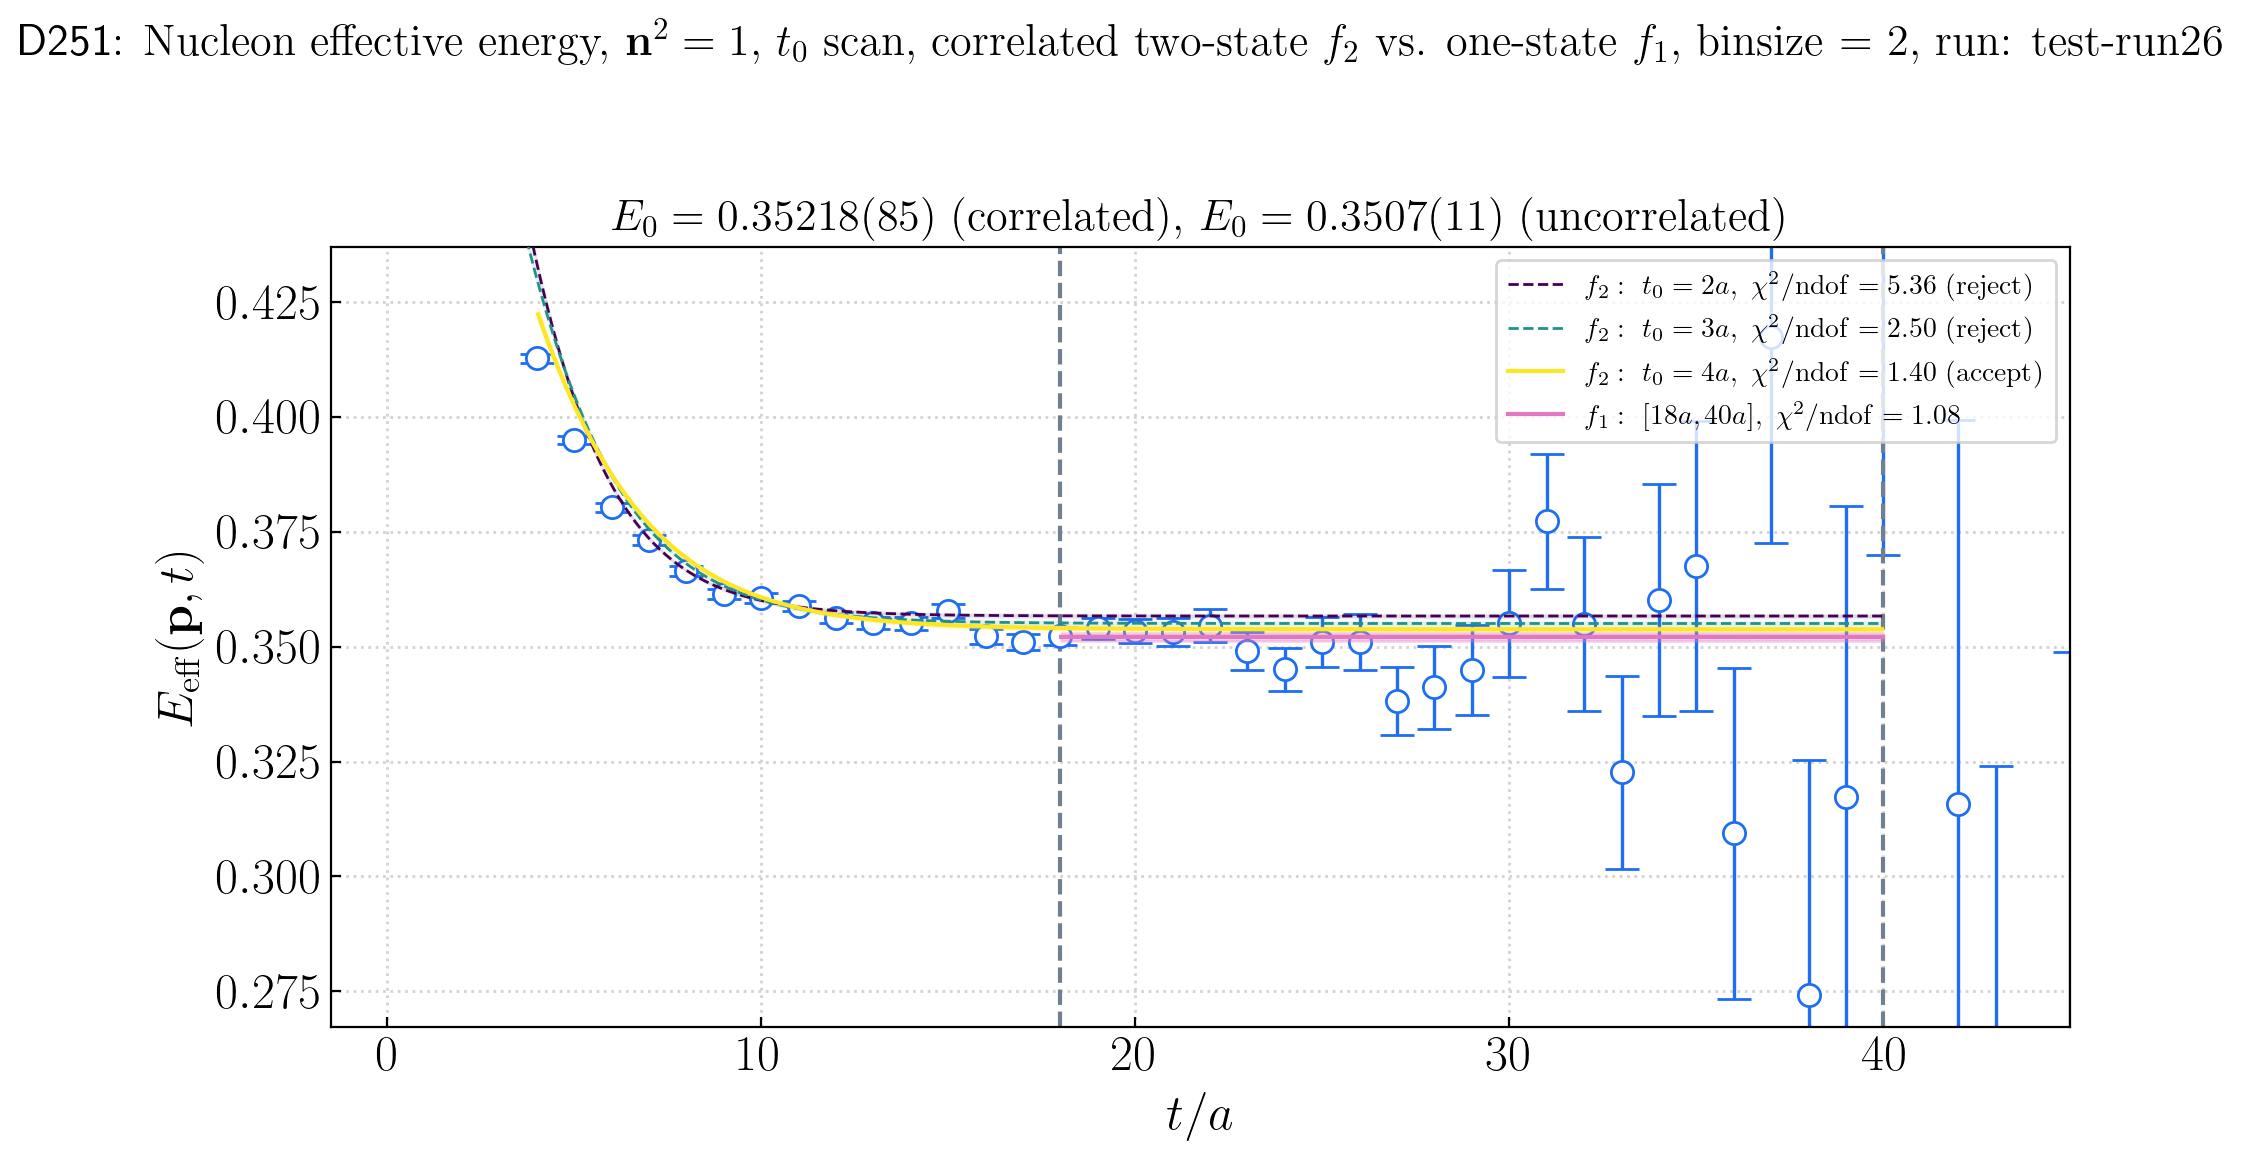

0.9429726671015655


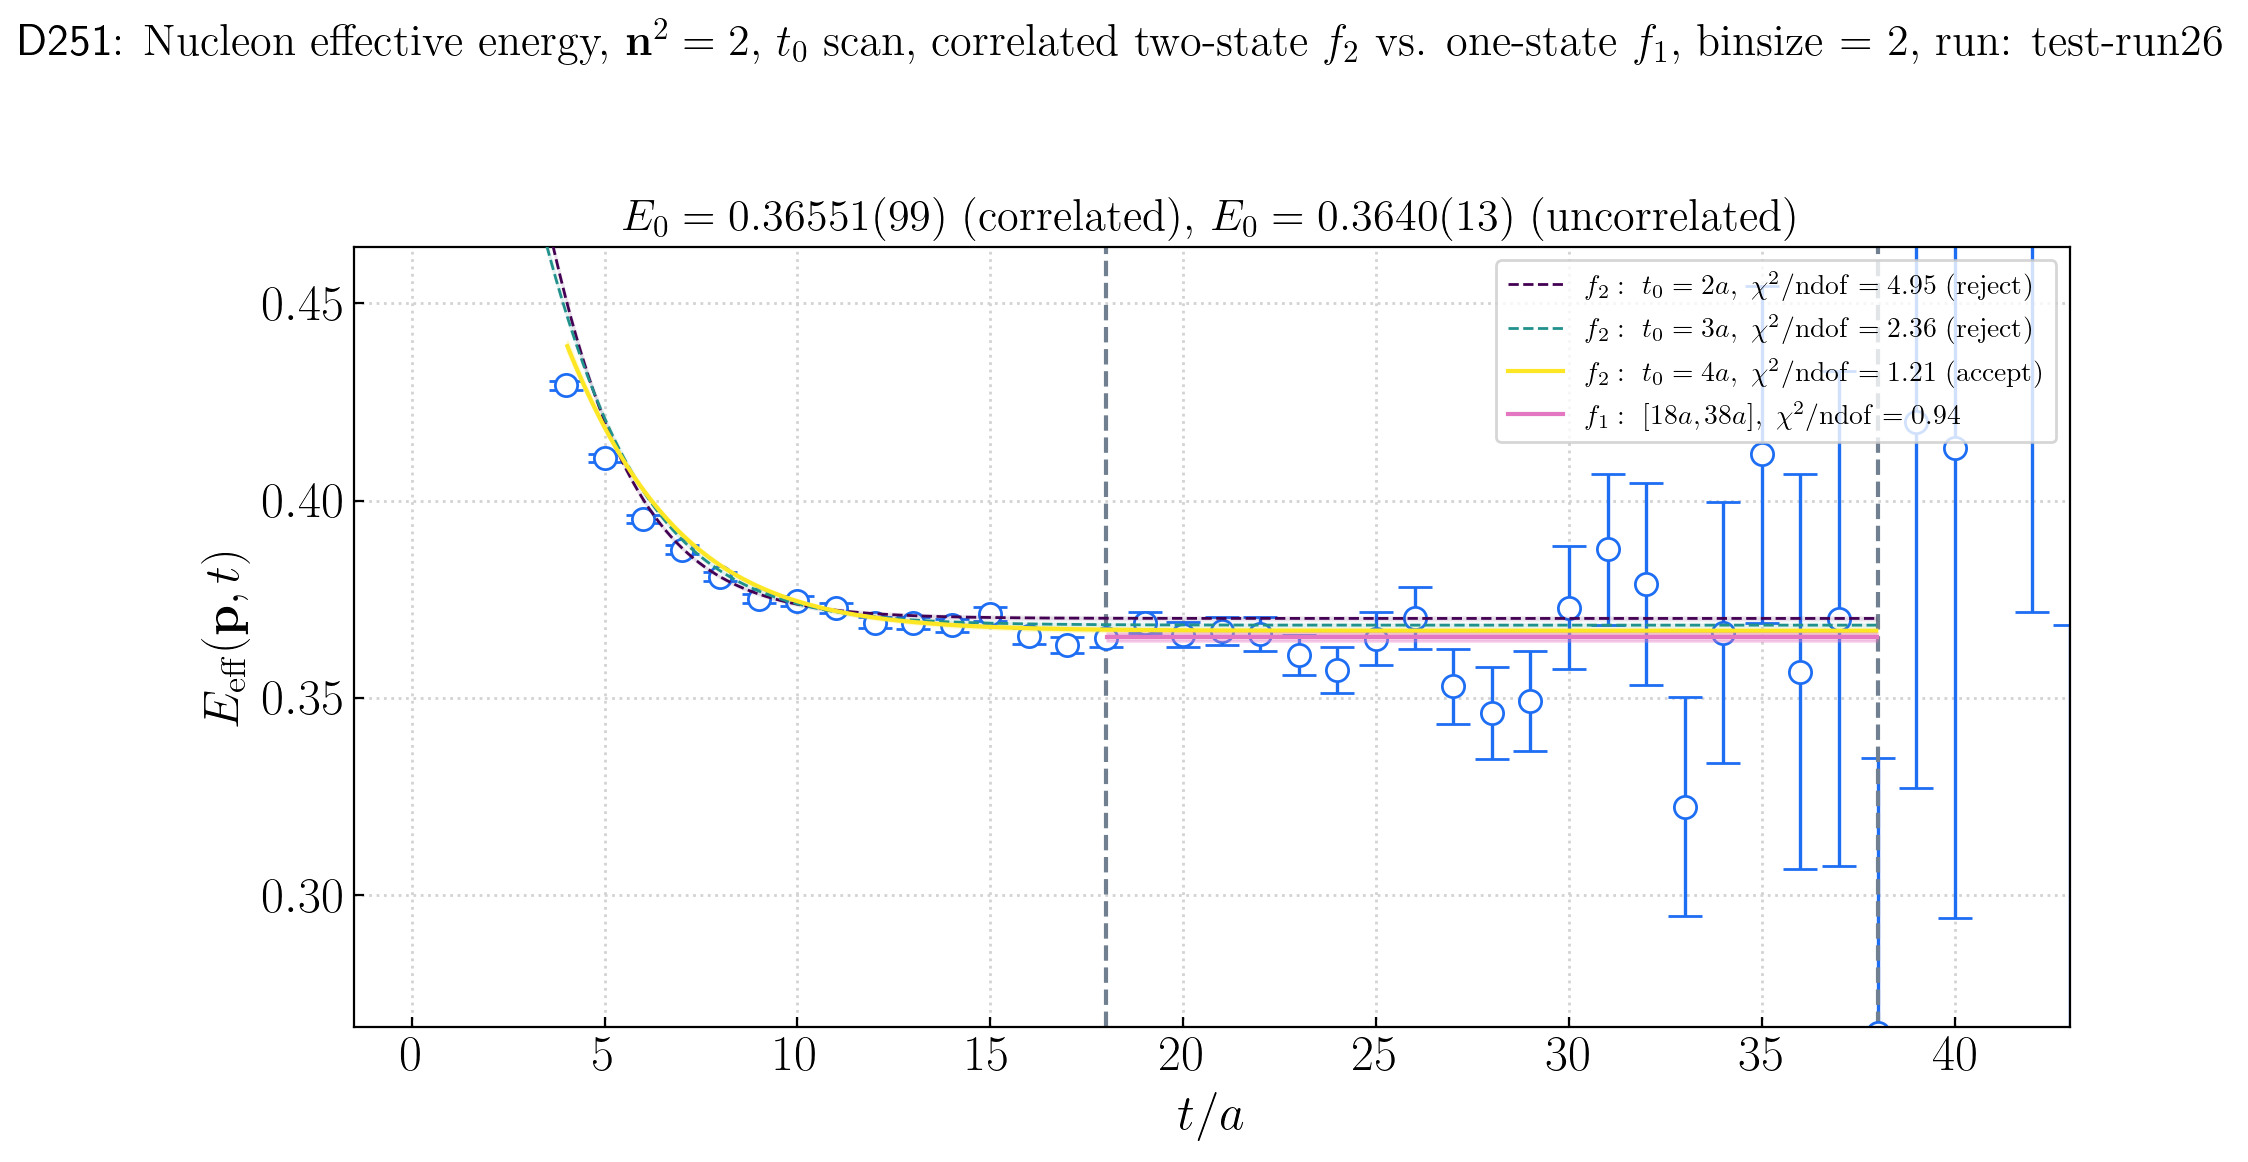

1.1324472319975083


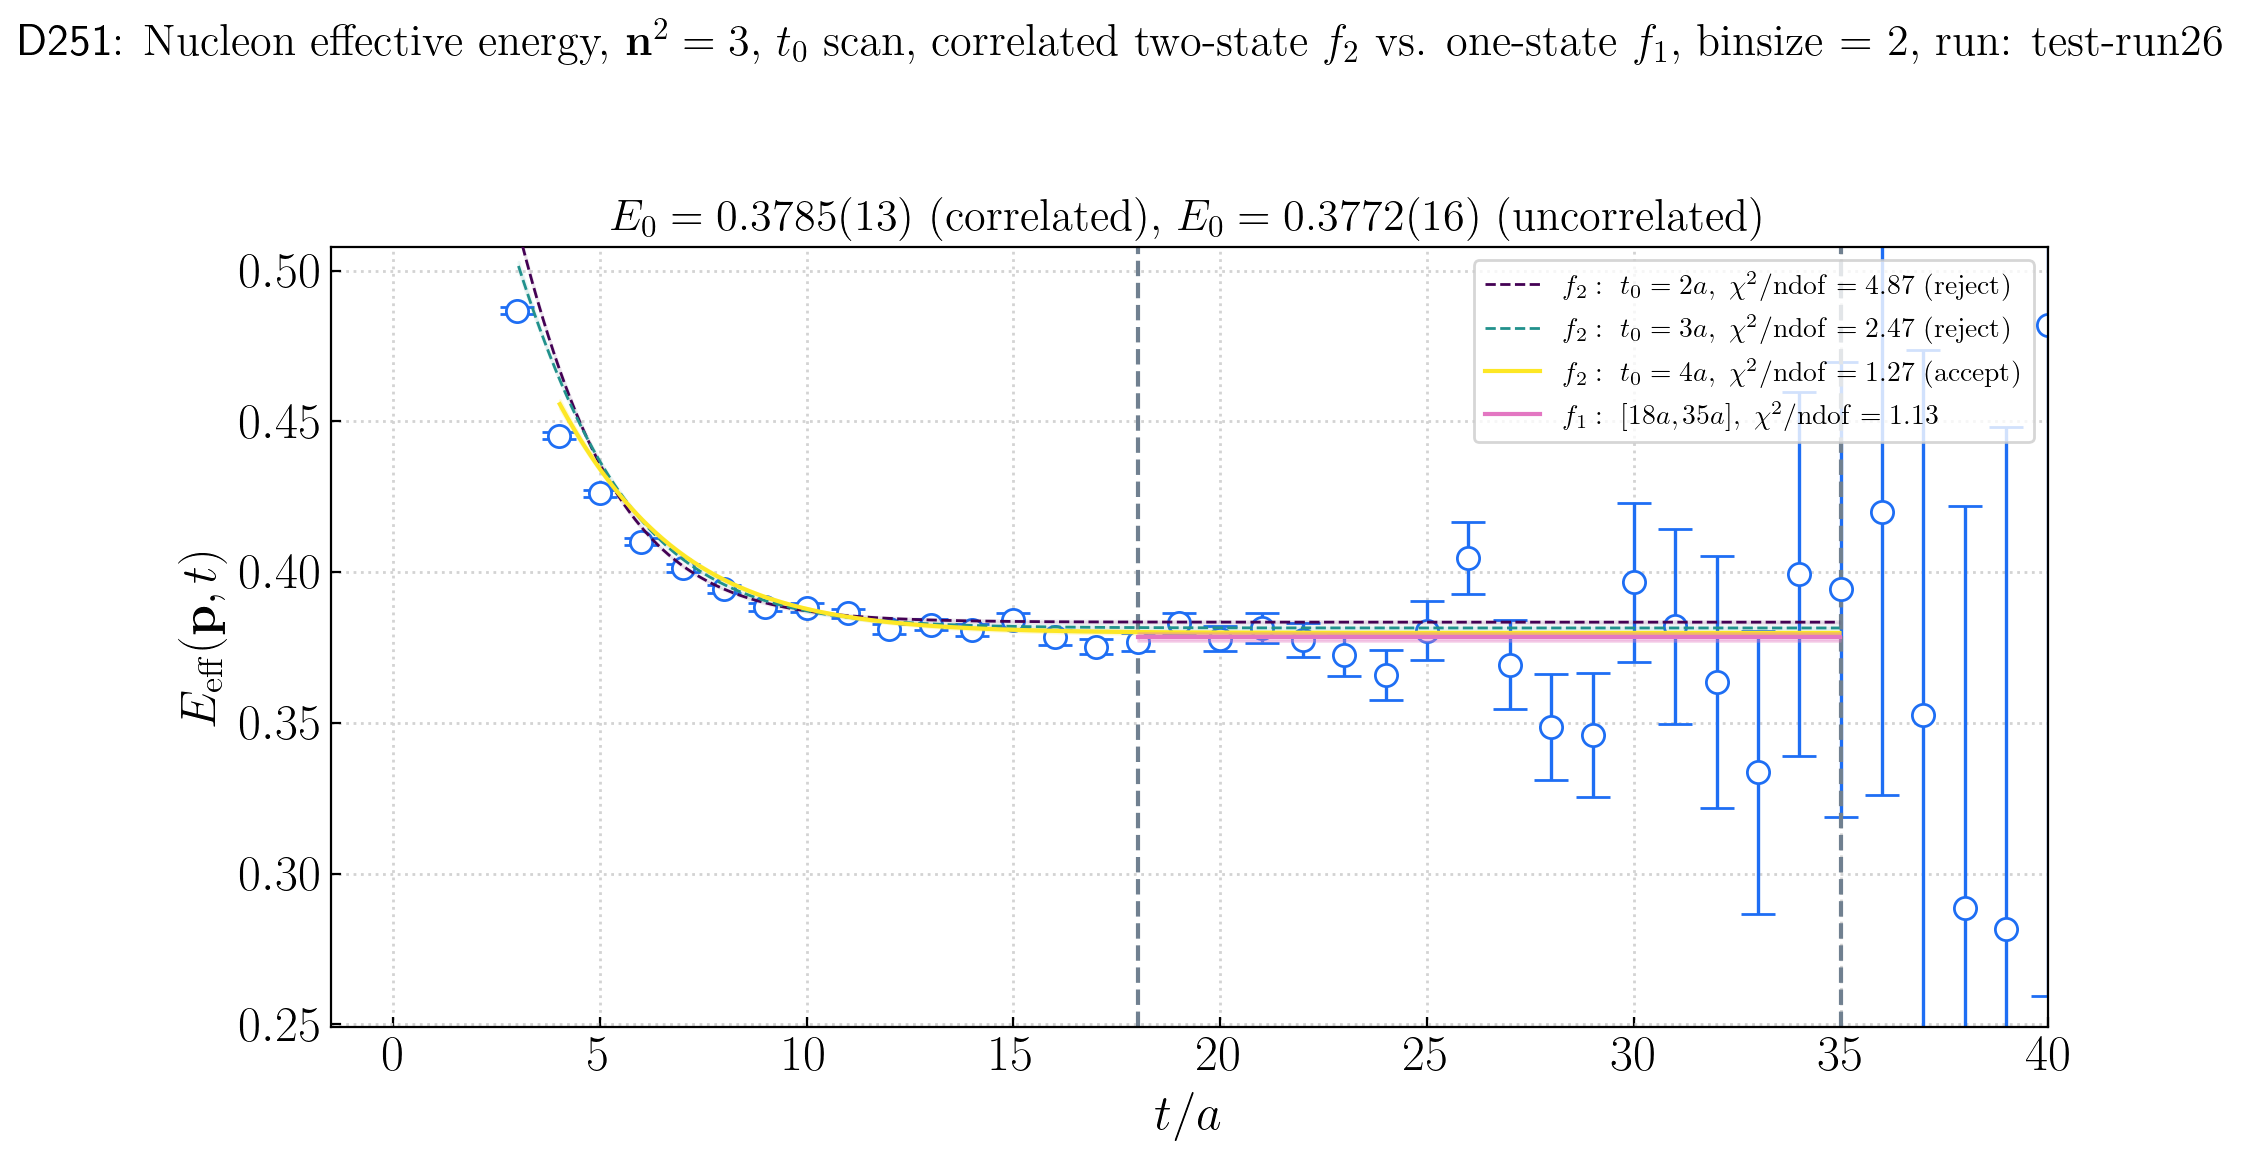

0.8248154672795441


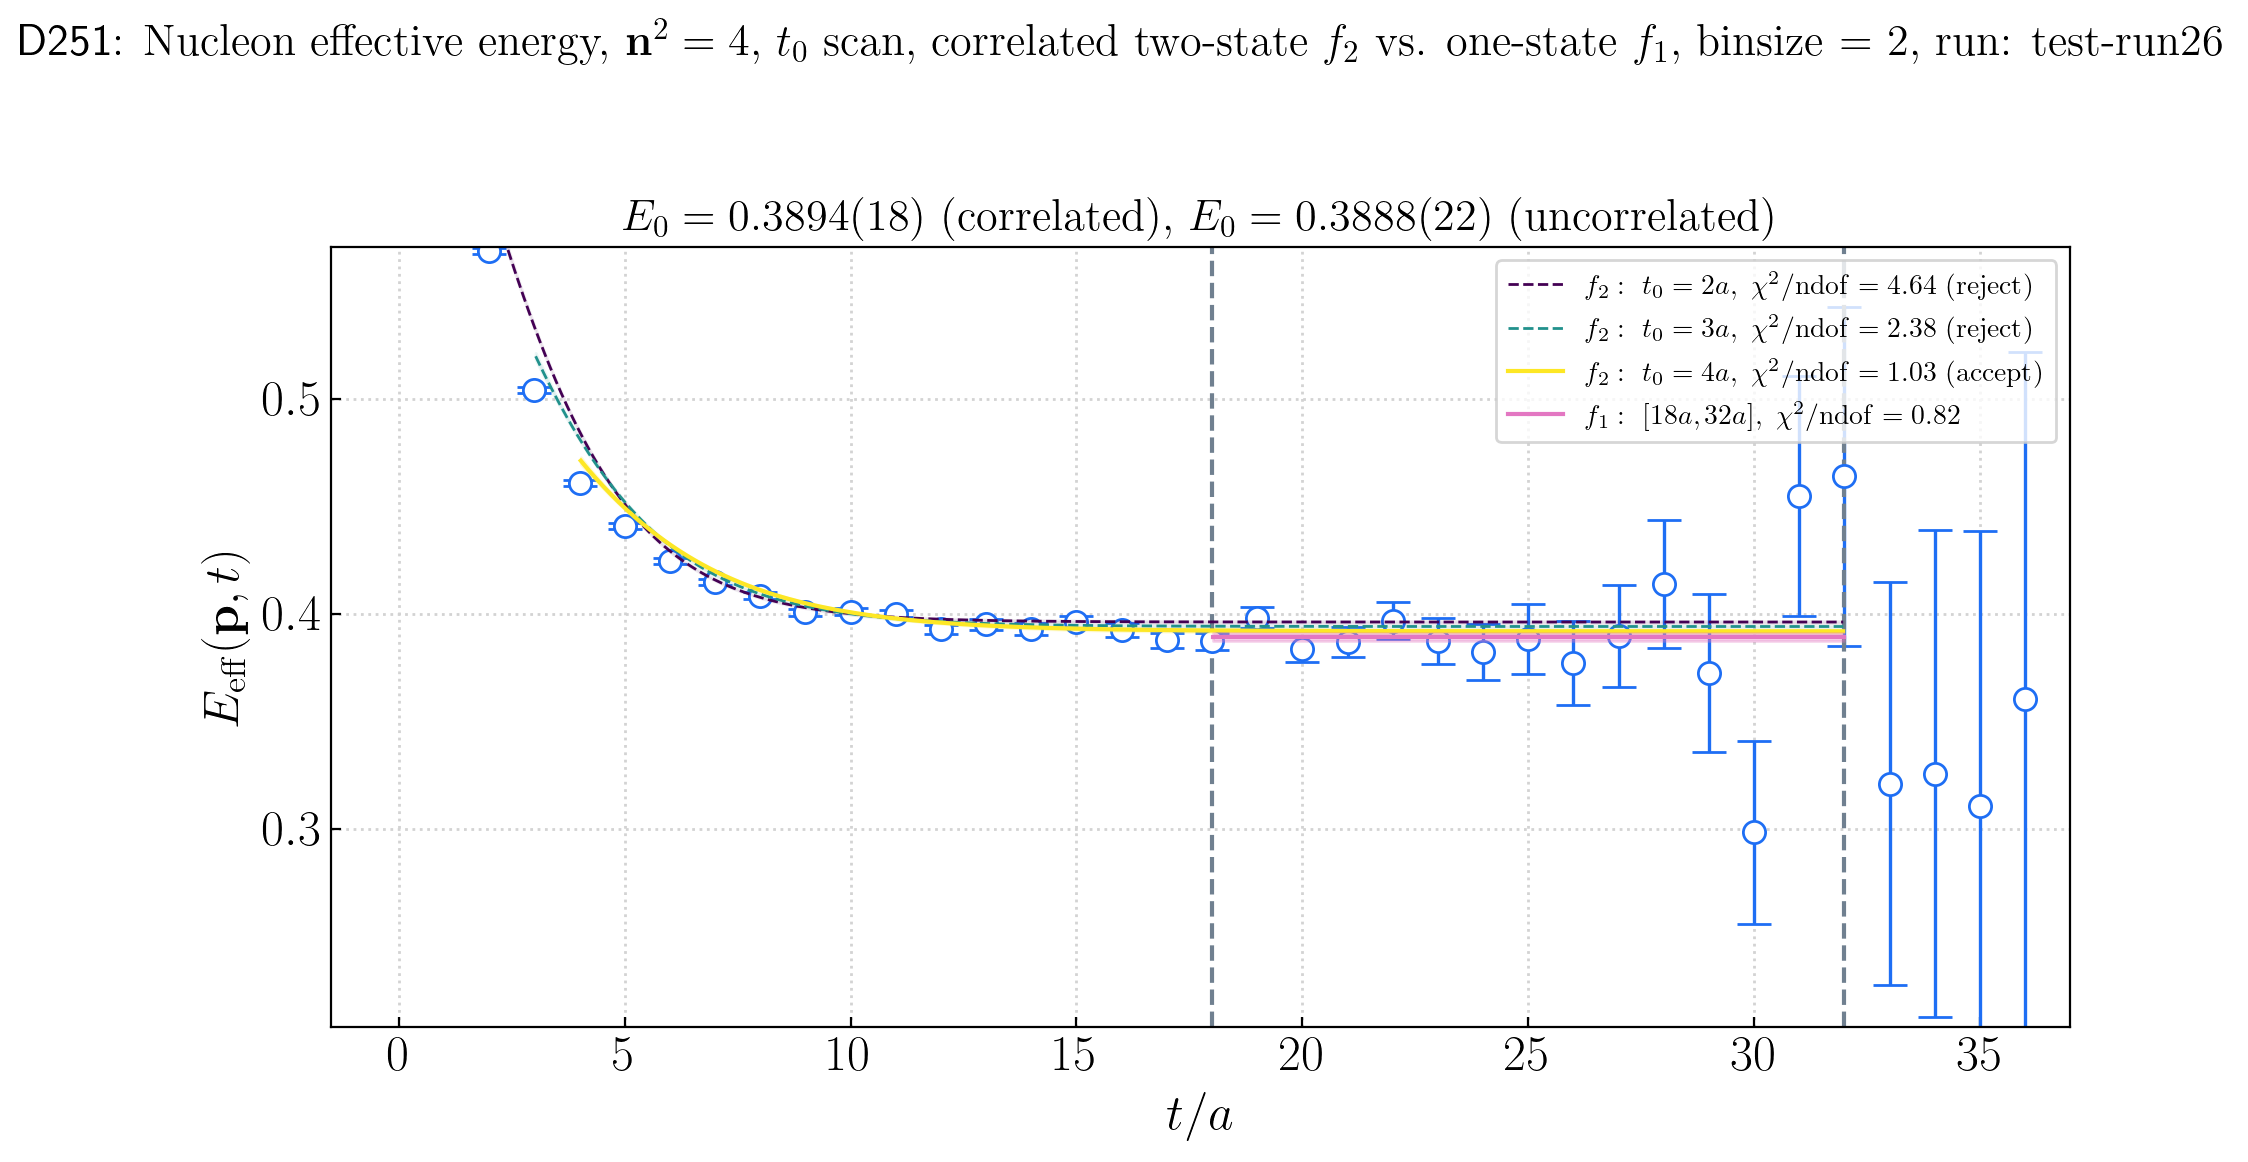

0.7501760150140495


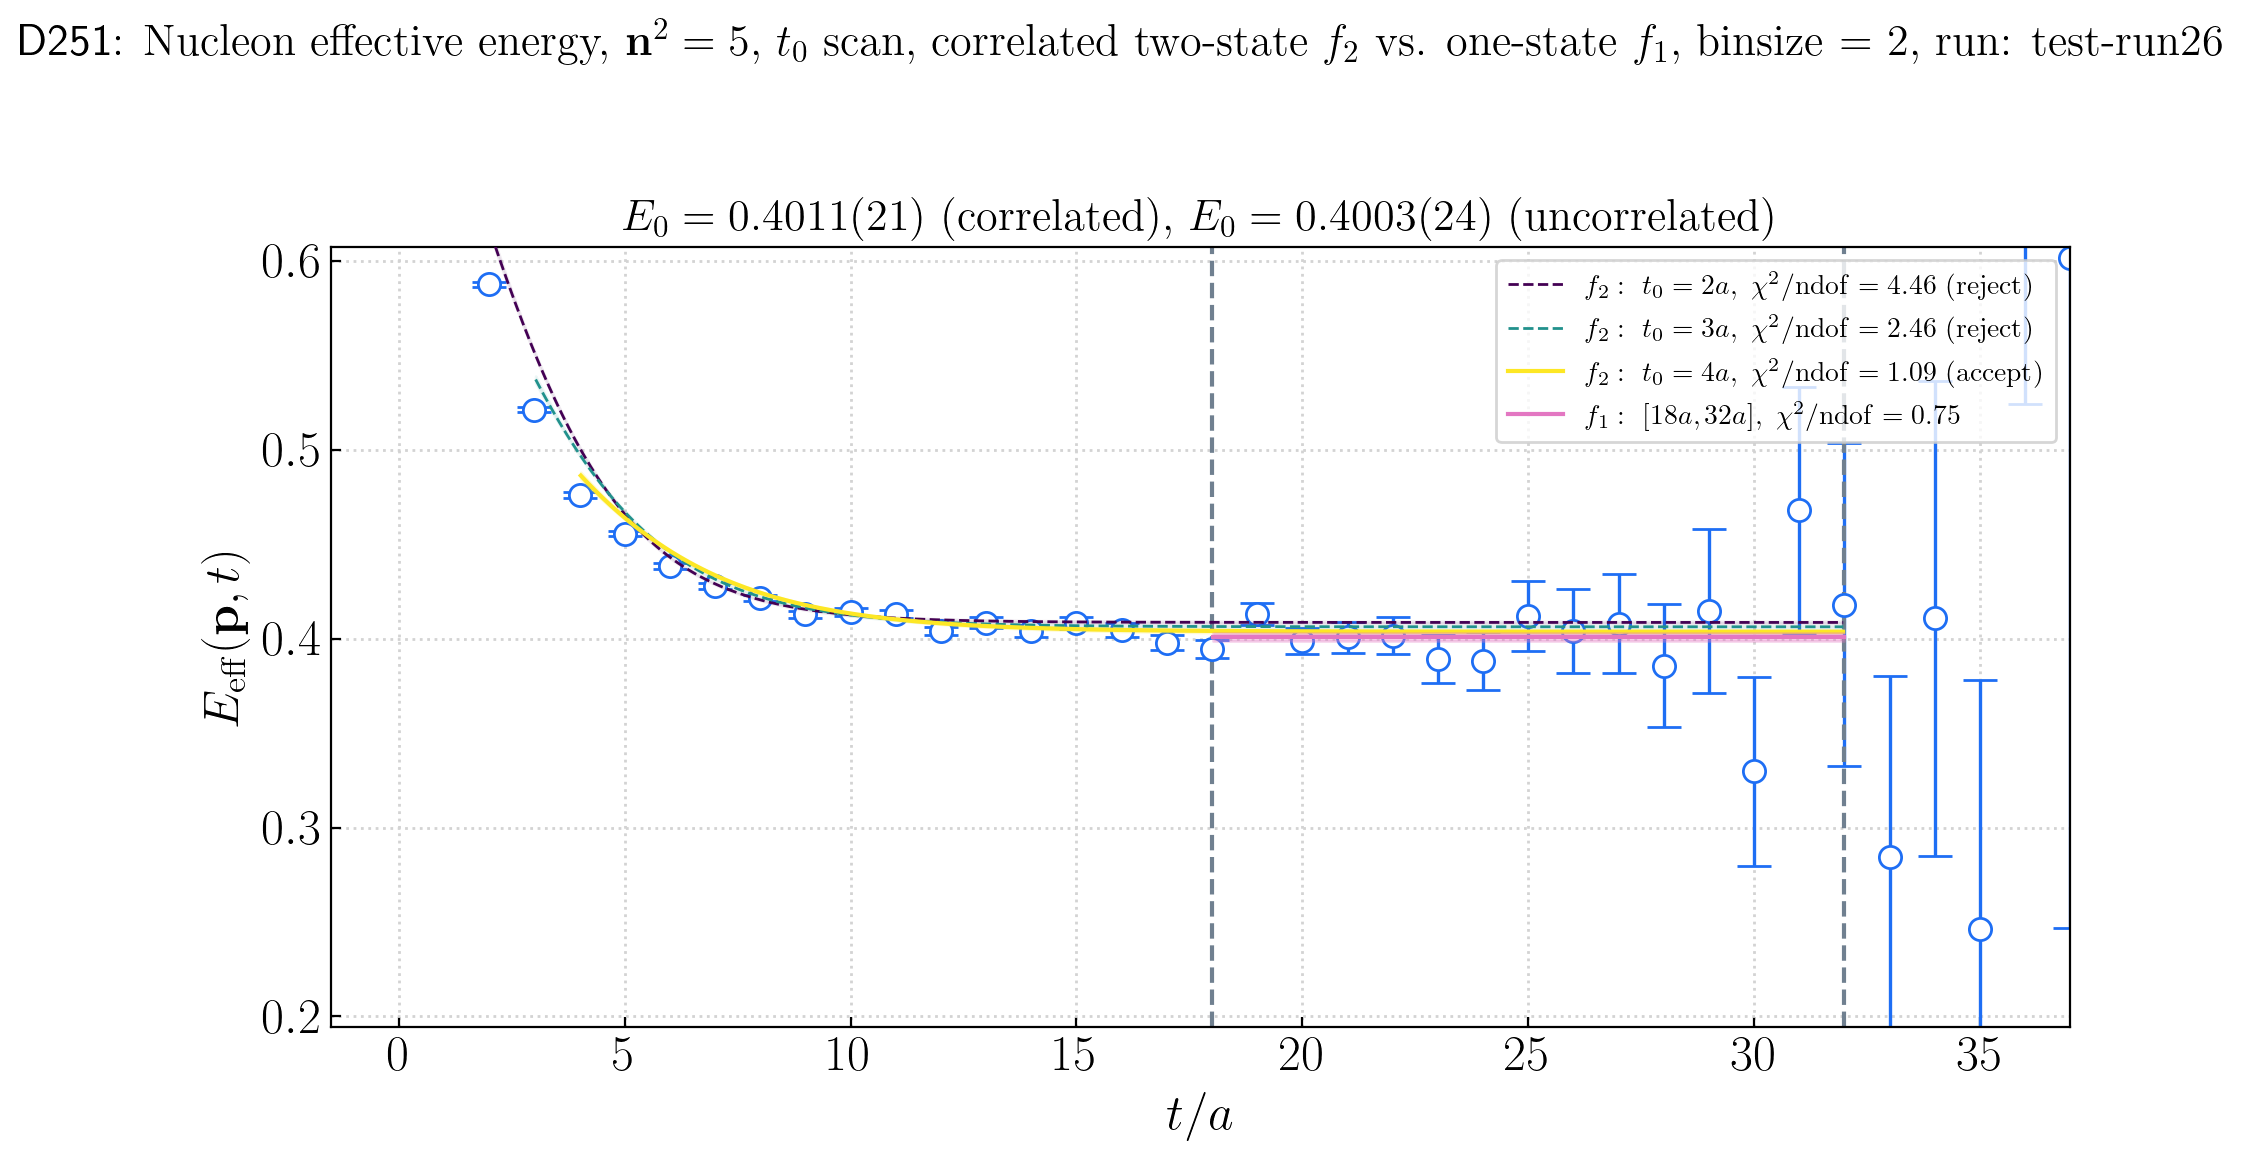

0.9816913861967381


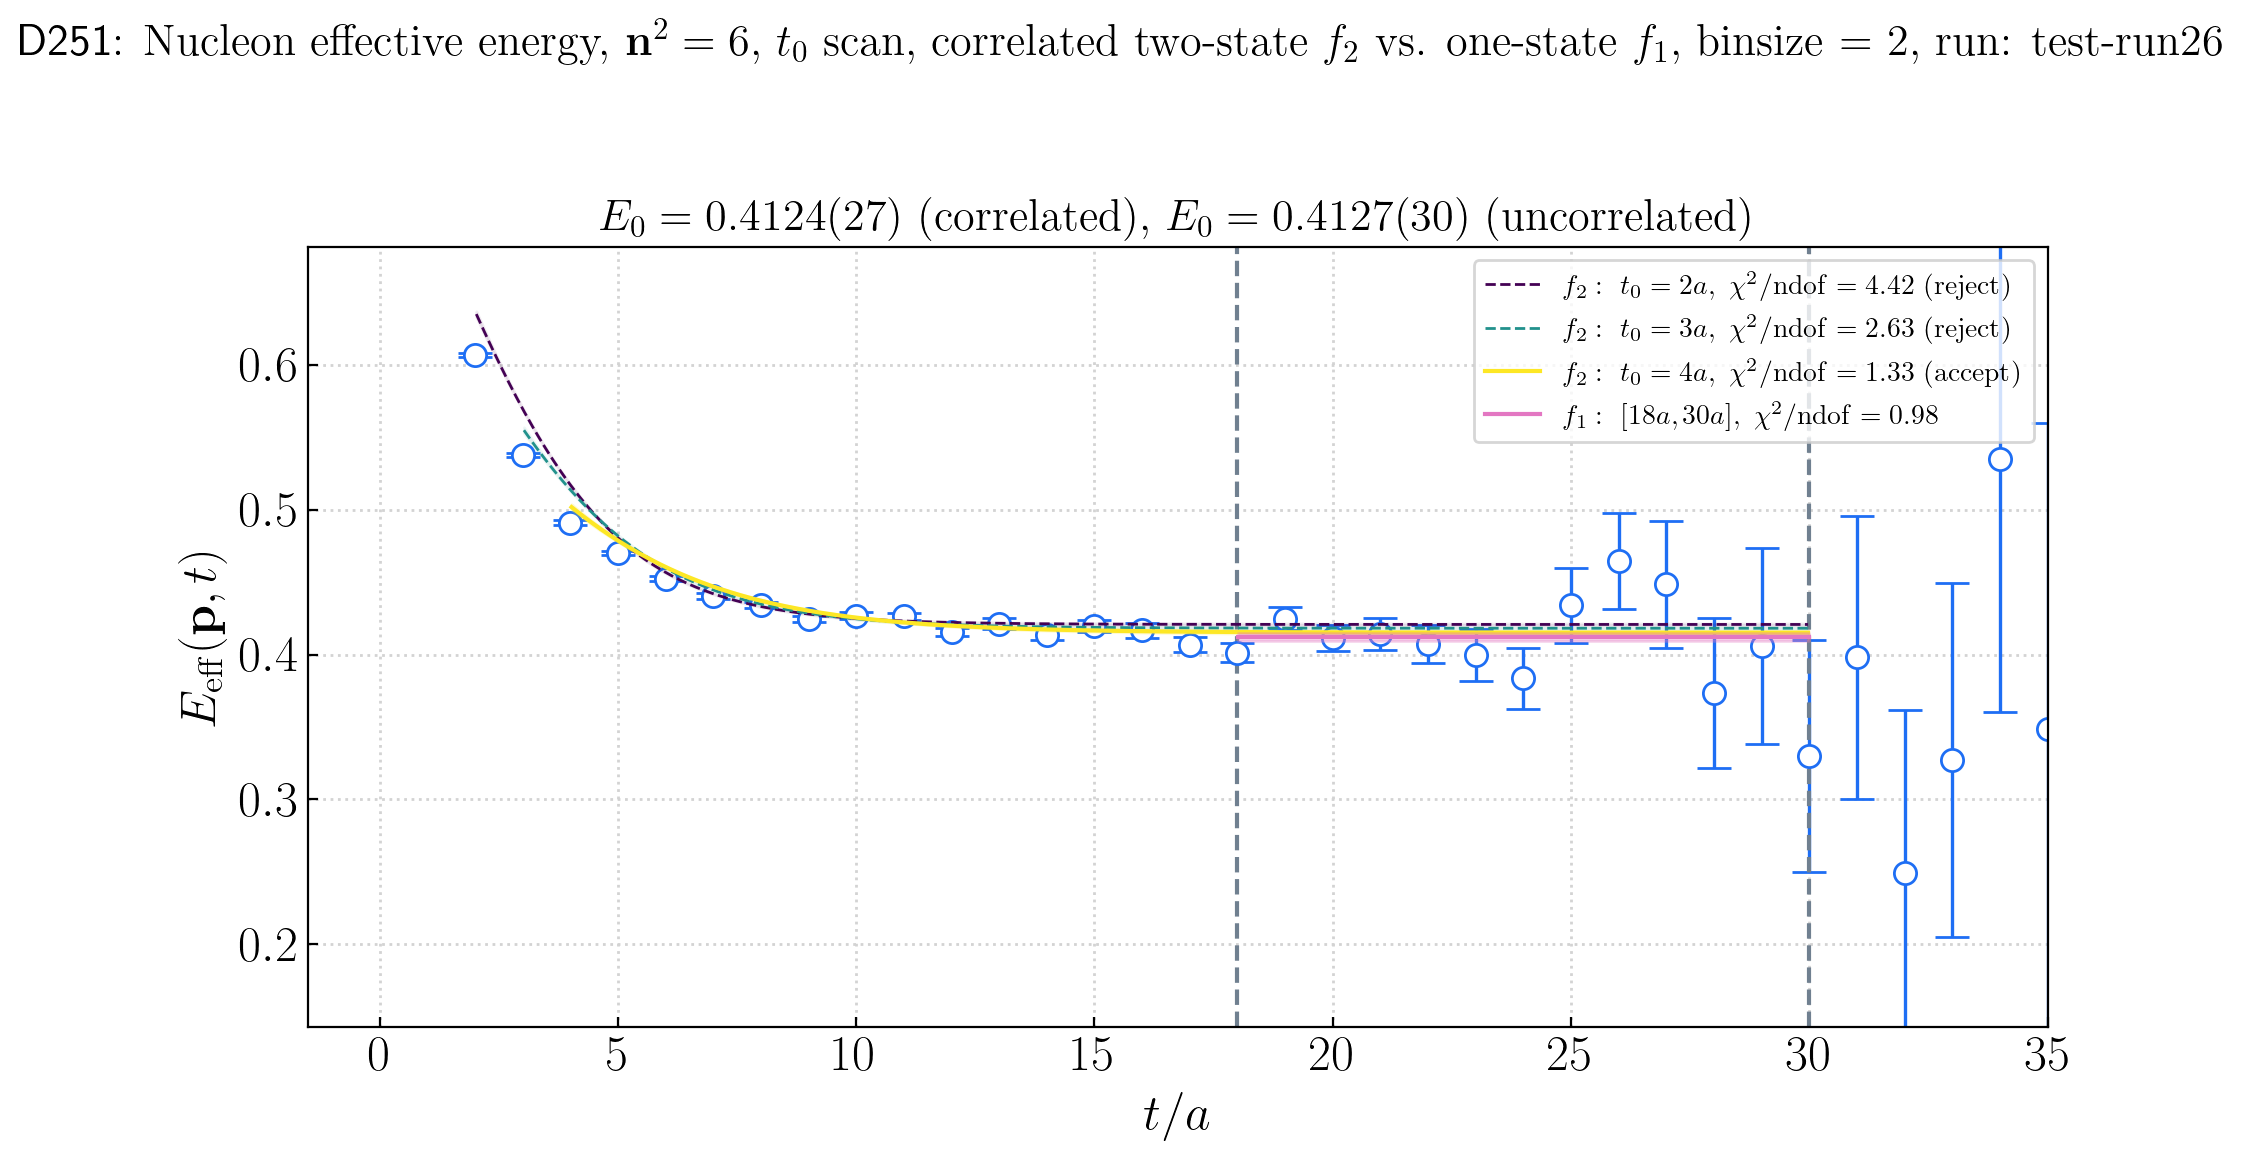

1.749225314499983


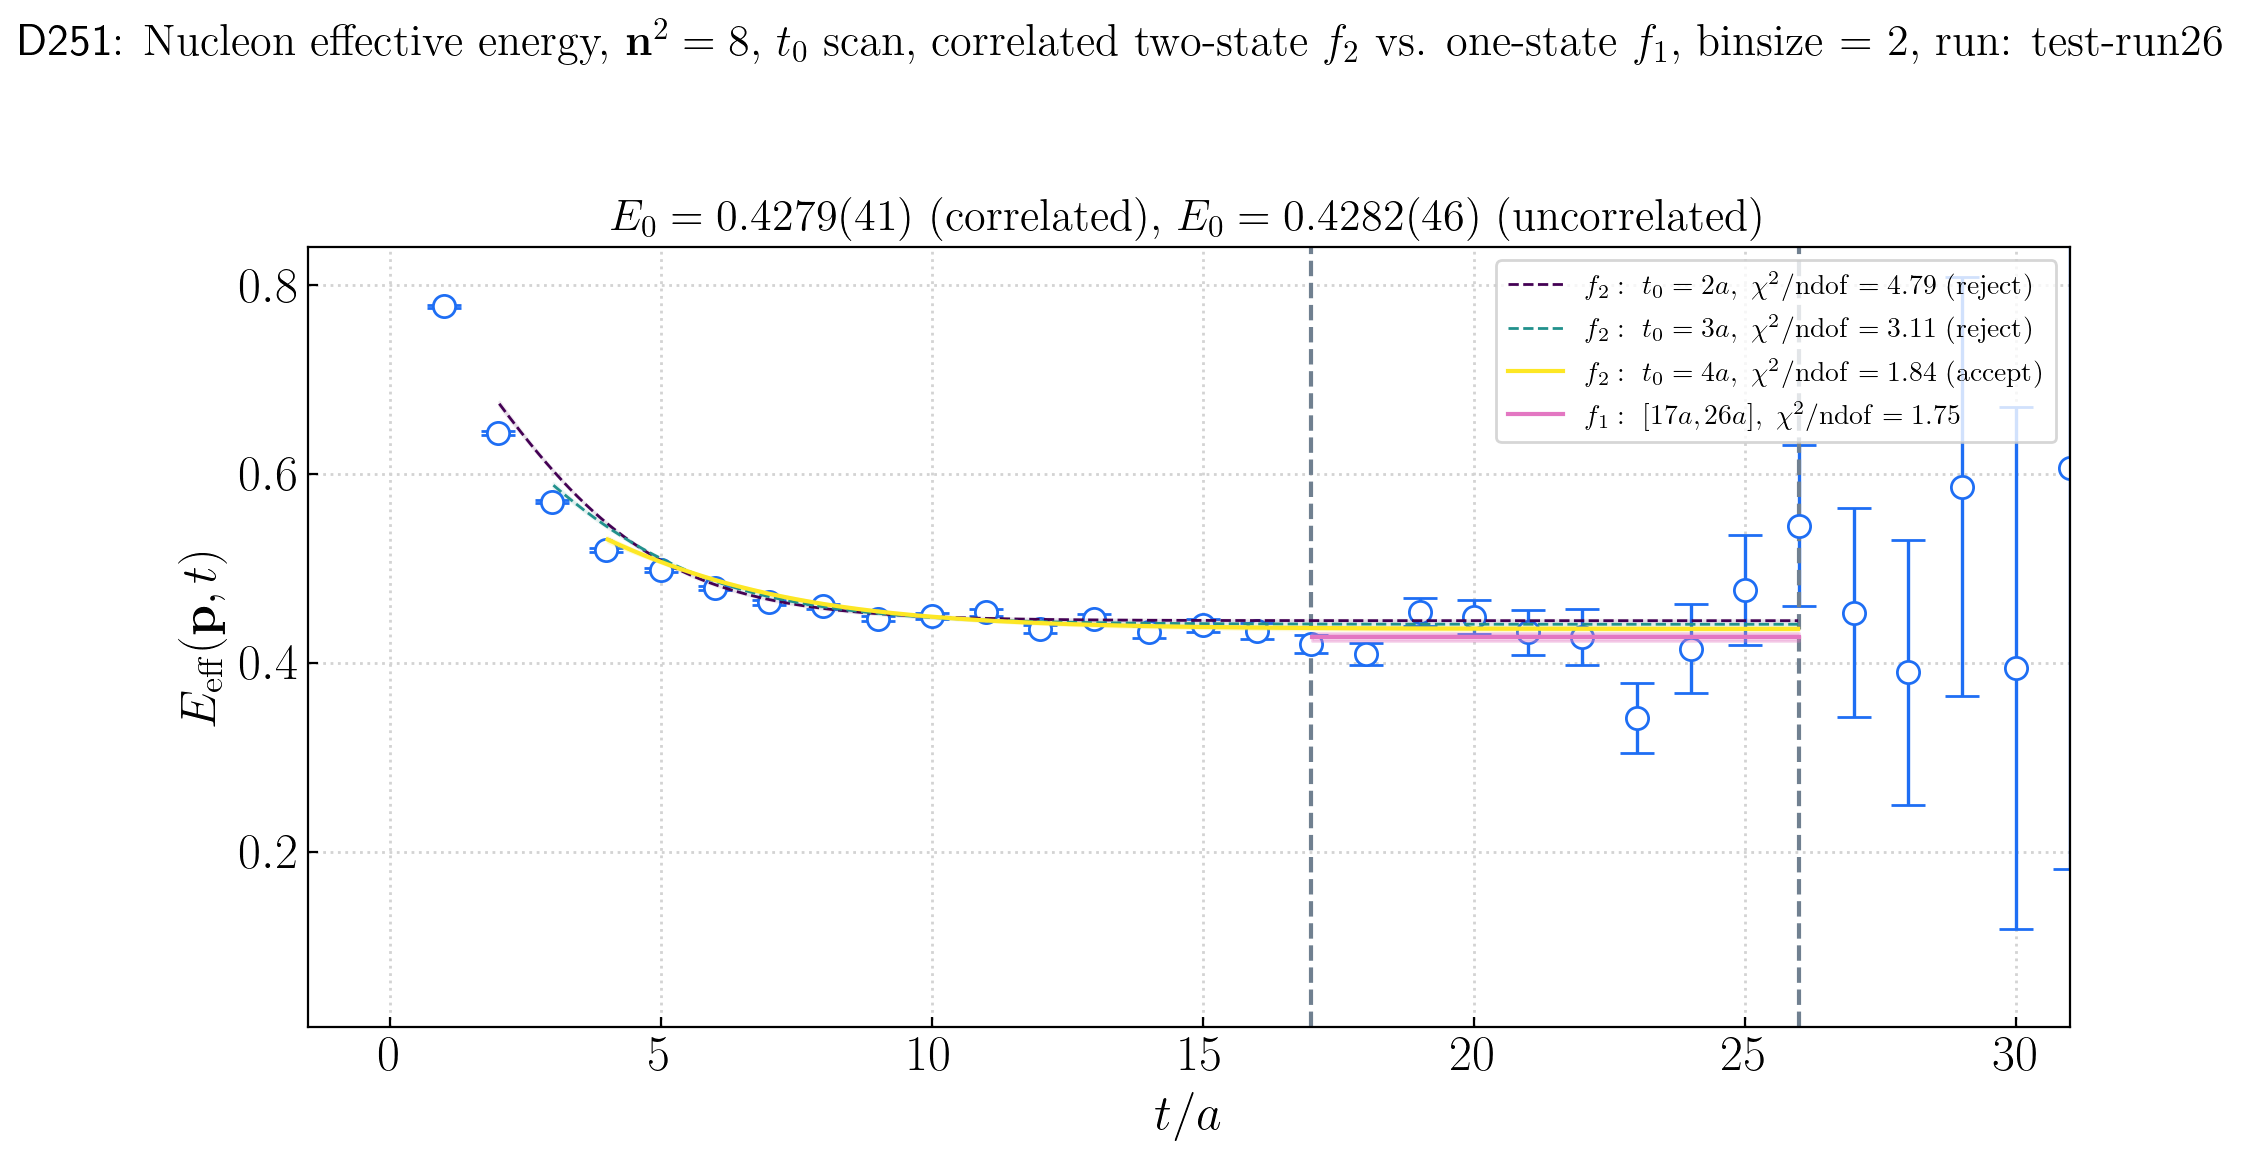

In [12]:
plt.rcParams.update({
    "font.size": 18,
    "font.family": "computer modern",
    "text.usetex": True,
    "figure.dpi": 200,
    "axes.prop_cycle":
        cycler(color=[
            "#1E6EF4",
            "#ff8d28",
            "#34C759",
            "#E7124D",
        ])
})
blue       = "#1E6EF4"
markersize = 8
capsize    = 6
linewidth  = 1
elinewidth = 1.2

chi2dof_max = 2.0

import matplotlib.cm as cm
import matplotlib.colors as mcolors

for nsquare in momentum_shells:
    one_state_fits = load_fits(run_dir, ensemble, nsquare, "one-state-exp", correlation_type, bin_size)
    one_state_fits_uncorr = load_fits(run_dir, ensemble, nsquare, "one-state-exp", "uncorrelated", bin_size)
    two_state_fits = load_fits(run_dir, ensemble, nsquare, "two-state-exp", "correlated", bin_size)

    if not one_state_fits:
        print(f"nsquare={nsquare}: no one-state fit, skipping")
        continue

    one  = one_state_fits[0]
    oneuncorr = one_state_fits_uncorr[0]
    tmin = one["tmin"]
    tmax = one["tmax"]
    E0_one = gv.gvar(one["E0"], one["E0_err"])
    E0_one_uncorr = gv.gvar(oneuncorr["E0"], oneuncorr["E0_err"])

    # sort two-state fits by t0 (= tmin field) so colors/legend are ordered
    two_state_fits = sorted(two_state_fits, key=lambda f: f["tmin"])

    # c2pt data → effective energy
    c2pt     = c2pt_per_nsquare[nsquare]
    n_res    = c2pt.shape[0]
    Eeff     = np.log(c2pt[:, :-1] / c2pt[:, 1:])
    Eeff_avg = np.mean(Eeff, axis=0)
    Eeff_err = np.std(Eeff, axis=0, ddof=0) * np.sqrt(n_res - 1)
    t        = np.arange(len(Eeff_avg))

    fig, ax = plt.subplots(figsize=(10, 6))

    # effective energy data
    ax.errorbar(t, Eeff_avg, Eeff_err,
                fmt="o", mfc="white", color=blue,
                markersize=markersize, capsize=capsize, elinewidth=elinewidth,
                zorder=2)

    # ---- ALL two-state starts ----
    n_two = len(two_state_fits)
    cmap  = cm.get_cmap("viridis")
    norm  = mcolors.Normalize(vmin=0, vmax=max(n_two - 1, 1))

    for j, two in enumerate(two_state_fits):
        tzero      = two["tmin"]
        chi2dof_2  = two["chi2dof"]
        accepted   = chi2dof_2 <= chi2dof_max
        color      = cmap(norm(j))
        ls         = "-" if accepted else "--"
        alpha_band = 0.20 if accepted else 0.08
        lw_line    = linewidth + 0.5 if accepted else linewidth
        tag        = r"\ (\mathrm{accept})" if accepted else r"\ (\mathrm{reject})"

        t_mid2 = 0.5 * (two["t_ext"][:-1] + two["t_ext"][1:])
        ax.plot(t_mid2, two["Eeff_cen_ext"],
                color=color, lw=lw_line, ls=ls, zorder=4,
                label=rf"$f_2:\ t_0={tzero}a,\ \chi^2/\mathrm{{ndof}}={chi2dof_2:.2f}{tag}$")
        ax.fill_between(t_mid2,
                        two["Eeff_cen_ext"] - two["Eeff_err_ext"],
                        two["Eeff_cen_ext"] + two["Eeff_err_ext"],
                        color=color, alpha=alpha_band, zorder=3)

    # ---- one-state production band ----
    t_mid = 0.5 * (one["t_ext"][:-1] + one["t_ext"][1:])
    ax.plot(t_mid, one["Eeff_cen_ext"], color="tab:pink", lw=linewidth + 0.5, zorder=5,
            label=rf"$f_1:\ [{tmin}a,{tmax}a],\ \chi^2/\mathrm{{ndof}}={one['chi2dof']:.2f}$")
    print(one['chi2dof'])
    ax.fill_between(t_mid,
                    one["Eeff_cen_ext"] - one["Eeff_err_ext"],
                    one["Eeff_cen_ext"] + one["Eeff_err_ext"],
                    color="tab:pink", alpha=0.30, zorder=4)

    # FIT WINDOW MARKERS (production)
    ax.axvline(tmin, color="slategrey", linestyle="--", linewidth=1.5)
    ax.axvline(tmax, color="slategrey", linestyle="--", linewidth=1.5)

    # zoom around the one-state E0 plateau
    y_pad = max(100 * one["E0_err"], 0.02)
    ax.set_ylim(one["E0"] - y_pad, one["E0"] + y_pad)
    ax.set_xlim(-1.5, tmax + 5)

    ax.set_title(rf"$E_0 = {E0_one}$ (correlated), $E_0 = {E0_one_uncorr}$ (uncorrelated)", fontsize=16)
    ax.set_xlabel(r"$t/a$")
    ax.set_ylabel(r"$E_{\mathrm{eff}}(\mathbf{p}, t)$")
    ax.legend(fontsize=10, loc="upper right")
    ax.grid(color="lightgrey", linestyle=":", linewidth=1)
    ax.tick_params(direction="in")

    fig.suptitle(rf"$\mathsf{{{ensemble}}}$: Nucleon effective energy, "
                 rf"$\mathbf{{n}}^2 = {nsquare}$, $t_0$ scan, correlated two-state $f_2$ vs. one-state $f_1$, "
                 rf"binsize = {bin_size}, run: {run_id}",
                 fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.96])

    # figure_path = pathlib.Path(f"/home/ck/phd/plots/effective_energies/nsquare{nsquare:02d}")
    # figure_path.mkdir(parents=True, exist_ok=True)
    # figure_tag  = f"{ensemble}-nsquare{nsquare:02d}-Eeff-tzero-scan-{run_id}.pdf"
    # plt.savefig(figure_path / figure_tag)
    plt.show()